In [1]:
#importing libraries for MLP
import pandas as pd
import numpy as np
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.metrics import confusion_matrix,accuracy_score, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras import regularizers

In [2]:
from google.colab import files
file = files.upload()

Saving full_dataset.csv to full_dataset.csv


In [5]:
data = pd.read_csv('full_dataset.csv')
display(data.head())

,cpg_density,genomic_location,regulatory_score,conservation_score,methylation_status
0,0.799343,0.949839,0.297447,0.268438,1
1,0.672347,0.831158,0.456644,0.477923,1
2,0.829538,0.614908,0.262274,0.567279,0
3,1.000000,0.438266,0.407612,1.000000,1
4,0.653169,0.774556,0.000000,0.761311,0


In [7]:
data.shape

(1000, 5)

In [15]:
print(data.isnull().sum())

cpg_density           0
genomic_location      0
regulatory_score      0
conservation_score    0
methylation_status    0
dtype: int64


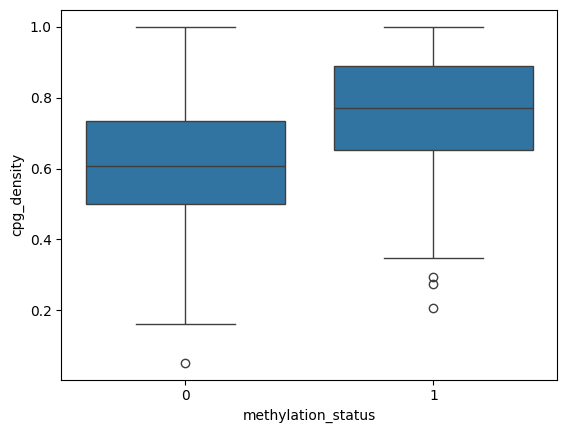

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='methylation_status',
            y='cpg_density',
            data=data)
plt.show()

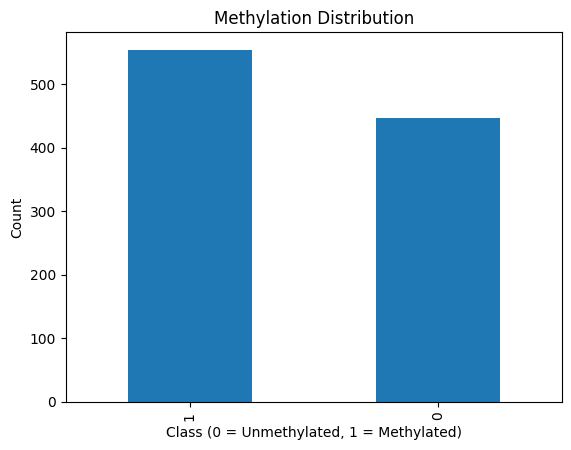

In [21]:
import matplotlib.pyplot as plt

data['methylation_status'].value_counts().plot(kind='bar')
plt.title("Methylation Distribution")
plt.xlabel("Class (0 = Unmethylated, 1 = Methylated)")
plt.ylabel("Count")
plt.show()

In [22]:
counts = data['methylation_status'].value_counts()

print("Unmethylated (0):", counts[0])
print("Methylated (1):", counts[1])

Unmethylated (0): 446
Methylated (1): 554


In [9]:
data.corr(numeric_only=True)

,cpg_density,genomic_location,regulatory_score,conservation_score,methylation_status
cpg_density,1.000000,-0.050191,0.032928,-0.008950,0.408027
genomic_location,-0.050191,1.000000,-0.011774,-0.057364,0.334472
regulatory_score,0.032928,-0.011774,1.000000,0.021710,0.537536
conservation_score,-0.008950,-0.057364,0.021710,1.000000,0.264708
methylation_status,0.408027,0.334472,0.537536,0.264708,1.000000


In [10]:
#separating features and target

X = data.drop(['methylation_status'], axis=1)
y = data['methylation_status']

input_features_count = X.shape[1]
print(f"Total input features: {input_features_count}")
print(f"Features list: {list(X.columns)}")

Total input features: 4
Features list: ['cpg_density', 'genomic_location', 'regulatory_score', 'conservation_score']


In [12]:
#Scaling and Data Splitting

#Minmax scaler
scaler =  preprocessing.MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("--- Step 3: Scaling & Splitting Complete! ---")
print(f"Training samples: {X_train.shape[0]} rows")
print(f"Testing samples : {X_test.shape[0]} rows")


--- Step 3: Scaling & Splitting Complete! ---
Training samples: 800 rows
Testing samples : 200 rows


In [13]:
#Defining MLP NN

model = Sequential()

model.add(Input(shape=(input_features_count,)))

model.add(Dense(16, activation = 'relu'))

model.add(Dense(8,activation='relu'))

model.add(Dense(1, activation='sigmoid'))

print("--- Step 4: Model Architecture Defined! ---")
model.summary()

--- Step 4: Model Architecture Defined! ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225 (900.00 B)

 Trainable params: 225 (900.00 B)

 Non-trainable params: 0 (0.00 B)

In [17]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [20]:
# ==========================================
# STEP 6: MLP WITH L2 REGULARIZATION & EARLY STOPPING
# ==========================================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping

# 1. Define the Early Stopping callback (Same as your configuration)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# 2. Build the Architecture with L2 Penalty Penalties
model_l2 = Sequential()
model_l2.add(Input(shape=(input_features_count,)))

# First Hidden Layer + L2 penalty (0.01 penalty strength)
model_l2.add(Dense(16, activation='relu', kernel_regularizer=regularizers.l2(0.001)))

# Second Hidden Layer + L2 penalty
model_l2.add(Dense(8, activation='relu', kernel_regularizer=regularizers.l2(0.001)))

# Output Layer (Remains regular sigmoid)
model_l2.add(Dense(1, activation='sigmoid'))

# 3. Compile the network
model_l2.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print("--- Step 6: L2 Regularized Model Compiled Successfully! ---")

# 4. Train the model
history_l2 = model_l2.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

--- Step 6: L2 Regularized Model Compiled Successfully! ---
Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.5484 - loss: 0.6961 - val_accuracy: 0.6000 - val_loss: 0.6762
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5484 - loss: 0.6914 - val_accuracy: 0.6000 - val_loss: 0.6707
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5484 - loss: 0.6862 - val_accuracy: 0.6000 - val_loss: 0.6657
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5484 - loss: 0.6805 - val_accuracy: 0.6000 - val_loss: 0.6591
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5484 - loss: 0.6746 - val_accuracy: 0.6000 - val_loss: 0.6534
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5484 - loss: 0.6692 - val_accuracy: 0.6000 - val_loss: 0.6463
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5484 - loss: 0.6624 - val_accuracy: 0.6000 - val_loss: 0.6411
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accur

In [33]:
# ==========================================
# STEP 7: FINAL EVALUATION & CONFUSION MATRIX
# (Video reference: 00:46:30 - 00:52:00)
# ==========================================

# 1. Generate prediction probabilities on the holdout test set
y_pred_probs = model_l2.predict(X_test)

# 2. Convert raw probabilities to binary 0 or 1 using the 0.5 threshold
y_pred = np.where(y_pred_probs > 0.55, 1, 0)

# 3. Calculate metrics
test_accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print("=============================================")
print(f"FINAL HOLDOUT TEST ACCURACY: {test_accuracy * 100:.2f}%")
print("=============================================")

print("\nCONFUSION MATRIX:")
print(conf_matrix)

print("\nCLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
FINAL HOLDOUT TEST ACCURACY: 97.00%

CONFUSION MATRIX:
[[ 91   2]
 [  4 103]]

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97        93
           1       0.98      0.96      0.97       107

    accuracy                           0.97       200
   macro avg       0.97      0.97      0.97       200
weighted avg       0.97      0.97      0.97       200



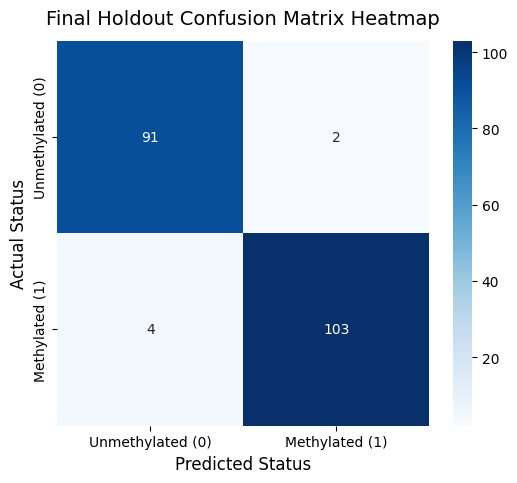

In [34]:
import seaborn as sns

plt.figure(figsize=(6, 5))

# Plot the heatmap with annotations
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Unmethylated (0)', 'Methylated (1)'],
    yticklabels=['Unmethylated (0)', 'Methylated (1)']
)

plt.title('Final Holdout Confusion Matrix Heatmap', fontsize=14, pad=12)
plt.xlabel('Predicted Status', fontsize=12)
plt.ylabel('Actual Status', fontsize=12)
plt.show()

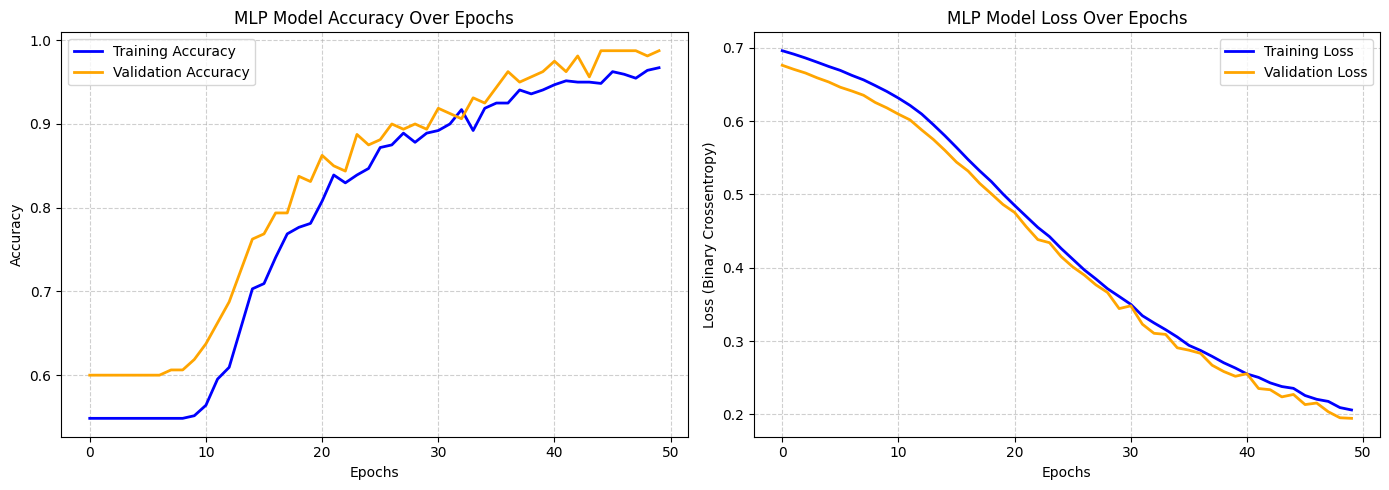

In [35]:
import matplotlib.pyplot as plt

# Set up a double-pane plotting figure
plt.figure(figsize=(14, 5))

# 1. PLOT ACCURACY CURVES
plt.subplot(1, 2, 1)
plt.plot(history_l2.history['accuracy'], label='Training Accuracy', color='blue', linewidth=2)
plt.plot(history_l2.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
plt.title('MLP Model Accuracy Over Epochs', fontsize=12)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# 2. PLOT LOSS CURVES
plt.subplot(1, 2, 2)
plt.plot(history_l2.history['loss'], label='Training Loss', color='blue', linewidth=2)
plt.plot(history_l2.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
plt.title('MLP Model Loss Over Epochs', fontsize=12)
plt.xlabel('Epochs')
plt.ylabel('Loss (Binary Crossentropy)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [41]:
import matplotlib.gridspec as gridspec
from matplotlib.animation import FuncAnimation
from matplotlib.patches import FancyArrowPatch, Circle, FancyBboxPatch
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import HTML

# ── 1. EXTRACT WEIGHTS ──────────────────────────────────────────────────────
w1, b1 = model_l2.layers[0].get_weights()
w2, b2 = model_l2.layers[1].get_weights()
w3, b3 = model_l2.layers[2].get_weights()

layer_sizes  = [4, 16, 8, 1]
layer_labels = ["Input\n(Genomic Features)", "Hidden 1\n(16 neurons · L2)",
                "Hidden 2\n(8 neurons · L2)", "Output\n(Sigmoid)"]
feature_names = ["CpG Density", "Genomic Loc.", "Regulatory Score", "Conservation"]

LAYER_X = [1.6, 4.2, 6.8, 9.4]

# ── 2. NODE LAYOUT ──────────────────────────────────────────────────────────
def _layout(layer_sizes, layer_x, v_scale=None):
    v_scale = v_scale or [1.0, 0.78, 1.1, 1.0]
    coords = []
    for i, (n, x) in enumerate(zip(layer_sizes, layer_x)):
        ys = np.linspace(-n / 2, n / 2, n) * v_scale[i] if n > 1 else np.array([0.0])
        coords.append(list(zip([x] * n, ys)))
    return coords

node_coords = _layout(layer_sizes, LAYER_X)

# ── 3. FORWARD PASS ─────────────────────────────────────────────────────────
def forward(x):
    a1 = np.maximum(0, x @ w1 + b1)
    a2 = np.maximum(0, a1 @ w2 + b2)
    a3 = 1 / (1 + np.exp(-(a2 @ w3 + b3)))
    return [x, a1, a2, a3]

# ── 4. COLOUR UTILITIES ─────────────────────────────────────────────────────
DARK_BG     = "#0d1117"
PANEL_BG    = "#161b22"
ACCENT_BLUE = "#58a6ff"
ACCENT_ORG  = "#e3b341"
ACCENT_RED  = "#f85149"
ACCENT_GRN  = "#3fb950"
TEXT_MAIN   = "#e6edf3"
TEXT_DIM    = "#8b949e"

node_cmap = LinearSegmentedColormap.from_list(
    "node", ["#21262d", "#1f6feb", "#58a6ff", ACCENT_ORG, "#ff7b72"], N=256)

weights_list = [w1, w2, w3]
max_ws = [np.max(np.abs(w)) + 1e-8 for w in weights_list]

# ── 5. BUILD FIGURE WITH TWO PANELS ─────────────────────────────────────────
fig = plt.figure(figsize=(17, 9.5), facecolor=DARK_BG)
gs  = gridspec.GridSpec(2, 2, width_ratios=[3, 1], height_ratios=[1, 1],
                        hspace=0.55, wspace=0.08,
                        left=0.01, right=0.99, top=0.93, bottom=0.04)

ax_net  = fig.add_subplot(gs[:, 0])   # full-height network panel
ax_bar  = fig.add_subplot(gs[0, 1])   # top-right: activation bar chart
ax_prob = fig.add_subplot(gs[1, 1])   # bottom-right: prediction gauge

for ax in (ax_net, ax_bar, ax_prob):
    ax.set_facecolor(PANEL_BG)
    for spine in ax.spines.values():
        spine.set_edgecolor("#30363d")

# header
fig.text(0.5, 0.975, "MLP · DNA Methylation Classifier",
         ha="center", va="top", fontsize=14, color=TEXT_MAIN, weight="bold")

SAMPLE_IDXS = np.arange(15)   # 15 test samples to animate

# pre-compute predictions for the gauge history sparkline
all_preds = []
for i in SAMPLE_IDXS:
    xv = X_test[i]
    acts = forward(xv)
    all_preds.append(float(acts[3][0]))


# ── 6. FRAME UPDATE ─────────────────────────────────────────────────────────
def update(frame):
    ax_net.cla(); ax_bar.cla(); ax_prob.cla()

    for ax in (ax_net, ax_bar, ax_prob):
        ax.set_facecolor(PANEL_BG)
        for spine in ax.spines.values():
            spine.set_edgecolor("#30363d")

    # ── data for this frame
    xv     = X_test[SAMPLE_IDXS[frame]]
    true_y = (y_test.iloc[SAMPLE_IDXS[frame]]
              if hasattr(y_test, "iloc") else y_test[SAMPLE_IDXS[frame]])
    acts   = forward(xv)
    pred   = float(acts[3][0])
    pred_class = int(pred >= 0.5)

    status_lbl   = "METHYLATED"   if true_y == 1 else "UNMETHYLATED"
    status_color = ACCENT_RED      if true_y == 1 else ACCENT_GRN
    correct      = pred_class == int(true_y)

    # ── NETWORK PANEL ──────────────────────────────────────────────────────
    ax_net.set_axis_off()
    ax_net.set_xlim(0.3, 11)
    ax_net.set_ylim(-10, 10)

    # title bar
    ax_net.text(5.5, 9.5, f"Sample #{SAMPLE_IDXS[frame]}  ·  True label: {status_lbl}",
                ha="center", va="center", fontsize=11, color=TEXT_MAIN, weight="bold")
    verdict_col = ACCENT_GRN if correct else ACCENT_RED
    verdict_txt = "✓ Correct" if correct else "✗ Wrong"
    ax_net.text(10.3, 9.5, verdict_txt, ha="right", va="center",
                fontsize=11, color=verdict_col, weight="bold")

    # layer headers
    for x, lbl in zip(LAYER_X, layer_labels):
        ax_net.text(x, 8.8, lbl, ha="center", va="center",
                    fontsize=8.5, color=TEXT_DIM, weight="bold")

    # ── synapses (connections)
    for l in range(len(layer_sizes) - 1):
        wm   = weights_list[l]
        mw   = max_ws[l]
        ins  = node_coords[l]
        outs = node_coords[l + 1]
        for i, (x1, y1) in enumerate(ins):
            for o, (x2, y2) in enumerate(outs):
                w_val  = wm[i, o]
                alpha  = min(abs(w_val) / mw, 1.0) * 0.40
                lw     = max((abs(w_val) / mw) * 1.8, 0.15)
                color  = "#ff7b72" if w_val > 0 else "#79c0ff"
                ax_net.plot([x1, x2], [y1, y2],
                            color=color, alpha=alpha, linewidth=lw, zorder=1)

    # ── nodes
    for l_idx, layer in enumerate(node_coords):
        layer_acts = acts[l_idx]
        max_act    = np.max(np.abs(layer_acts)) + 1e-8

        for n_idx, (x, y) in enumerate(layer):
            act_val   = float(layer_acts[n_idx])
            intensity = np.clip(act_val / max_act, 0, 1)
            nc        = node_cmap(intensity)

            # radius varies by layer
            radii = [0.20, 0.13, 0.16, 0.26]
            r = radii[l_idx]

            edge_col = {0: ACCENT_BLUE, 1: "#8b949e", 2: "#8b949e", 3: ACCENT_ORG}[l_idx]
            lw_node  = {0: 1.6, 1: 1.0, 2: 1.0, 3: 2.2}[l_idx]

            circle = Circle((x, y), r, facecolor=nc, edgecolor=edge_col,
                            linewidth=lw_node, zorder=3)
            ax_net.add_patch(circle)

            # labels
            if l_idx == 0:
                ax_net.text(x - 0.32, y,
                            f"{feature_names[n_idx]}\n{act_val:.3f}",
                            ha="right", va="center", fontsize=8,
                            color=TEXT_MAIN)
            elif l_idx == 3:
                ax_net.text(x + 0.38, y,
                            f"{pred:.4f}",
                            ha="left", va="center", fontsize=10,
                            color=ACCENT_ORG, weight="bold")

    # ── BAR CHART: hidden layer 2 activations ──────────────────────────────
    h2 = acts[2]
    bars = ax_bar.barh(np.arange(len(h2)), h2,
                       color=[node_cmap(v / (np.max(h2) + 1e-8)) for v in h2],
                       edgecolor="#30363d", linewidth=0.6, height=0.7)
    ax_bar.set_xlim(0, np.max(h2) * 1.15 + 1e-6)
    ax_bar.set_yticks(np.arange(len(h2)))
    ax_bar.set_yticklabels([f"N{i}" for i in range(len(h2))],
                           fontsize=7, color=TEXT_DIM)
    ax_bar.set_xlabel("Activation", fontsize=8, color=TEXT_DIM)
    ax_bar.tick_params(colors=TEXT_DIM, labelsize=7)
    ax_bar.set_title("Hidden Layer 2 Activations", fontsize=9,
                     color=TEXT_MAIN, pad=4)
    for spine in ax_bar.spines.values():
        spine.set_edgecolor("#30363d")
    ax_bar.tick_params(axis="both", colors=TEXT_DIM)

    # ── GAUGE: prediction score history ────────────────────────────────────
    past_preds = all_preds[: frame + 1]
    xp = np.arange(len(past_preds))
    ax_prob.plot(xp, past_preds, color=ACCENT_BLUE, linewidth=1.8, zorder=2)
    ax_prob.fill_between(xp, past_preds, 0.5,
                          where=[p >= 0.5 for p in past_preds],
                          color=ACCENT_RED, alpha=0.25, zorder=1)
    ax_prob.fill_between(xp, past_preds, 0.5,
                          where=[p < 0.5 for p in past_preds],
                          color=ACCENT_GRN, alpha=0.25, zorder=1)
    ax_prob.axhline(0.5, color=TEXT_DIM, linewidth=0.8, linestyle="--")
    ax_prob.scatter([frame], [pred],
                    color=status_color, s=55, zorder=5, edgecolors="white", linewidths=0.8)
    ax_prob.set_xlim(-0.5, len(SAMPLE_IDXS) - 0.5)
    ax_prob.set_ylim(-0.05, 1.05)
    ax_prob.set_xlabel("Sample index", fontsize=8, color=TEXT_DIM)
    ax_prob.set_ylabel("P(Methylated)", fontsize=8, color=TEXT_DIM)
    ax_prob.set_title("Prediction History", fontsize=9, color=TEXT_MAIN, pad=4)
    ax_prob.tick_params(axis="both", colors=TEXT_DIM, labelsize=7)
    for spine in ax_prob.spines.values():
        spine.set_edgecolor("#30363d")
    ax_prob.text(len(SAMPLE_IDXS) - 0.6, 0.97, "Meth.",
                 ha="right", fontsize=7, color=ACCENT_RED, alpha=0.7)
    ax_prob.text(len(SAMPLE_IDXS) - 0.6, 0.03, "Unmeth.",
                 ha="right", fontsize=7, color=ACCENT_GRN, alpha=0.7)

    return []


# ── 7. RENDER ───────────────────────────────────────────────────────────────
print("Rendering animation …")
anim = FuncAnimation(fig, update, frames=len(SAMPLE_IDXS),
                     interval=2000, blit=False)
plt.close()
HTML(anim.to_html5_video())

Rendering animation …
